LIBRARIES

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shutil
from tqdm import tqdm
import yaml
from collections import Counter

Load the constants and other configuration values.

In [13]:
# Load constants from config.yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Audio processing constants 
SAMPLING_RATE = config["audio_processing"]["sampling_rate"] # Resample the audio files with frequency 4 kHz, since wheezes and crackles are typically within frequency range 0–2 kHz
FRAME_LENGTH = config["audio_processing"]["frame_length"] # Use window size of 60 ms for each cycle
HOP_LENGTH = config["audio_processing"]["hop_length"] # Use 50% overlap
N_MFCC = config["audio_processing"]["n_mfcc"] # Extract the first 13 MFCCs
N_MELS = config["audio_processing"]["n_mels"] # Use 64 Mel Banks to extract the Log-Mel Spectrograms

FRAME_SIZE = int(FRAME_LENGTH*SAMPLING_RATE) # Calculate the amount of samples per frame
HOP_SIZE = int(HOP_LENGTH*SAMPLING_RATE) #  Calculate the amount of samples per hop

# Paths 
DATA_FOLDER = os.path.join(os.getcwd(), config["paths"]["data_folder"])
AUDIO_FOLDER = os.path.join(os.getcwd(), config["paths"]["audio_folder"])
RAW_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["raw_cycle_folder"])

# === Feature names ===
FEATURE_NAMES = (
    [f"MFCC_{i}" for i in range(N_MFCC)] +
    ["Spectral Centroid", "Spectral Bandwidth", "Zero Crossing Rate", "RMS Energy",
     "Spectral Rolloff", "Spectral Flux", "Spectral Flatness", "LogMel_Mean", "LogMel_Std"]
)

# === Device names ===
devices = ["AKGC417L", "LittC2SE", "Litt3200", "Meditron"]

REFERENCE_DEVICE = "AKGC417L"

Visualize device imbalance in Dataset

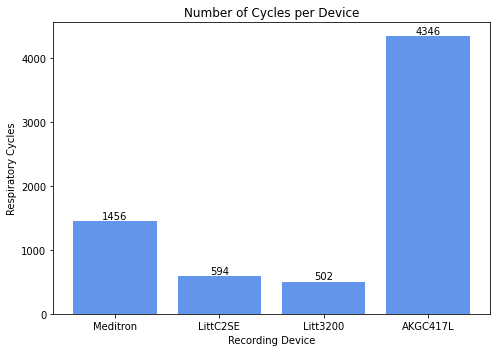

In [4]:
device_counts = Counter()

# Count the initial respiratory cycles of each device
for fname in os.listdir(RAW_CYCLE_FOLDER):
    if fname.endswith(".wav"):
        matched_device = next((d for d in devices if d in fname), None)
        if matched_device:
            device_counts[matched_device] += 1

# Bar plot
plt.figure(figsize=(7, 5))
plt.bar(device_counts.keys(), device_counts.values(), color="cornflowerblue")
plt.title("Number of Cycles per Device")
plt.xlabel("Recording Device")
plt.ylabel("Respiratory Cycles")

for i, (device, count) in enumerate(device_counts.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Extract acoustic features from raw .wav cycles

In [6]:
from utils.audio_preprocessing import extract_acoustic_features

OUTPUT_FEATURE_FILE = "raw_features.npy"
OUTPUT_FILENAMES_FILE = "raw_filenames.npy"

feature_list = []
filenames_list = []

wav_files = [f for f in os.listdir(RAW_CYCLE_FOLDER) if f.endswith(".wav")]

for fname in tqdm(wav_files, desc="Extracting features from raw files"):
    path = os.path.join(RAW_CYCLE_FOLDER, fname)
    y, sr = librosa.load(path, sr=SAMPLING_RATE)

    feats = extract_acoustic_features(
        y, sr,
        frame_size=FRAME_SIZE,
        hop_size=HOP_SIZE,
        n_mfcc=N_MFCC,
        n_mels=N_MELS
    )

    feats_flattened = feats.flatten()
    feature_list.append(feats_flattened)
    filenames_list.append(fname)

# Save as .npy
features_array = np.vstack(feature_list)
filenames_array = np.array(filenames_list)

np.save(OUTPUT_FEATURE_FILE, features_array)
np.save(OUTPUT_FILENAMES_FILE, filenames_array)

Extracting features from raw files: 100%|██████████| 6898/6898 [03:32<00:00, 32.40it/s]


Perform PCA / t-SNE

In [7]:
# Extract the device names of the .wav files
files = sorted([f for f in os.listdir(RAW_CYCLE_FOLDER) if f.endswith(".wav")])

# Correspond the file to the device and save in .npy file
device_labels = []
for fname in files:
    matched_device = next((d for d in devices if d in fname), None)
    if matched_device is None:
        raise ValueError(f"Device not found in filename: {fname}")
    device_labels.append(matched_device)

np.save("device_labels.npy", np.array(device_labels))

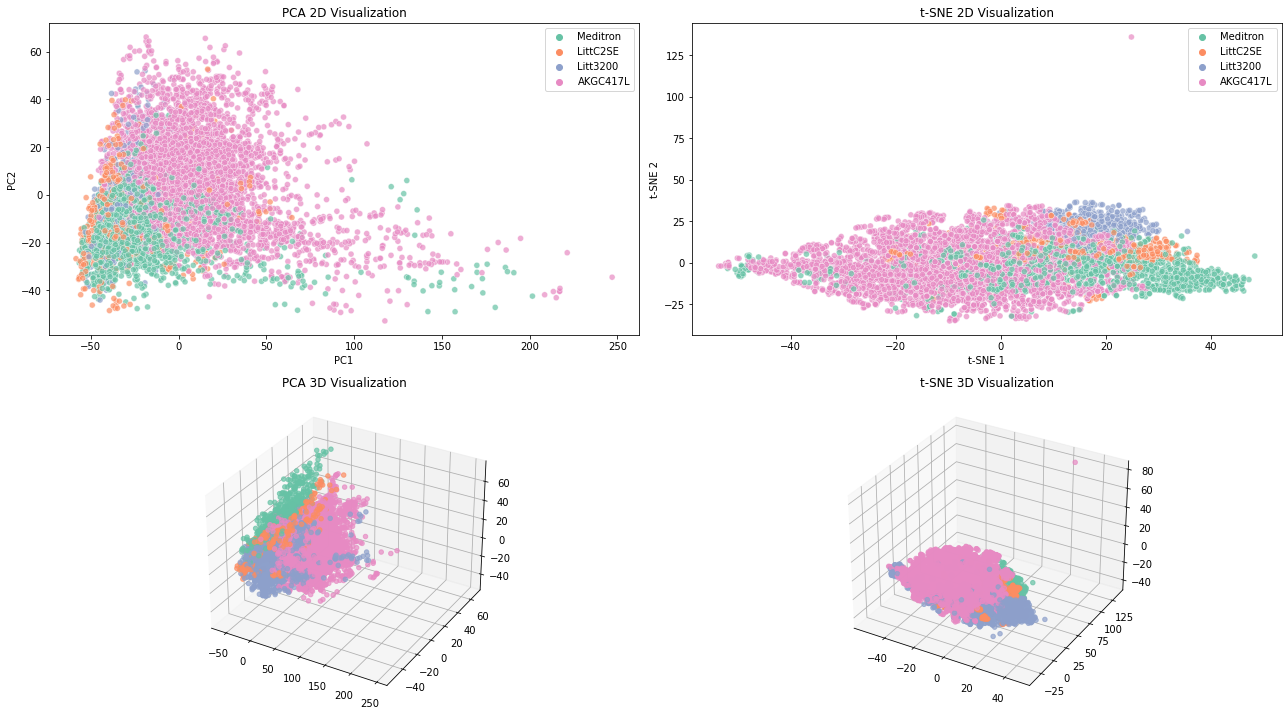

In [ ]:
from utils.visuals_and_statistics_plots import perform_pca_and_tsne

# Load the .npy files
raw_features = np.load("raw_features.npy")             
device_labels = np.load("device_labels.npy")   

# Run PCA and t-SNE
perform_pca_and_tsne(
    feature_matrix=raw_features,
    labels=device_labels,
    pca_components=0.90,   # Keep 90% of variance
    tsne_components=3,     # For 3D clustering
    perplexity=30
)

Use 502 cycles (Litt3200) from each device for balanced PCA/t-SNE to removes the bias from AKGC417L

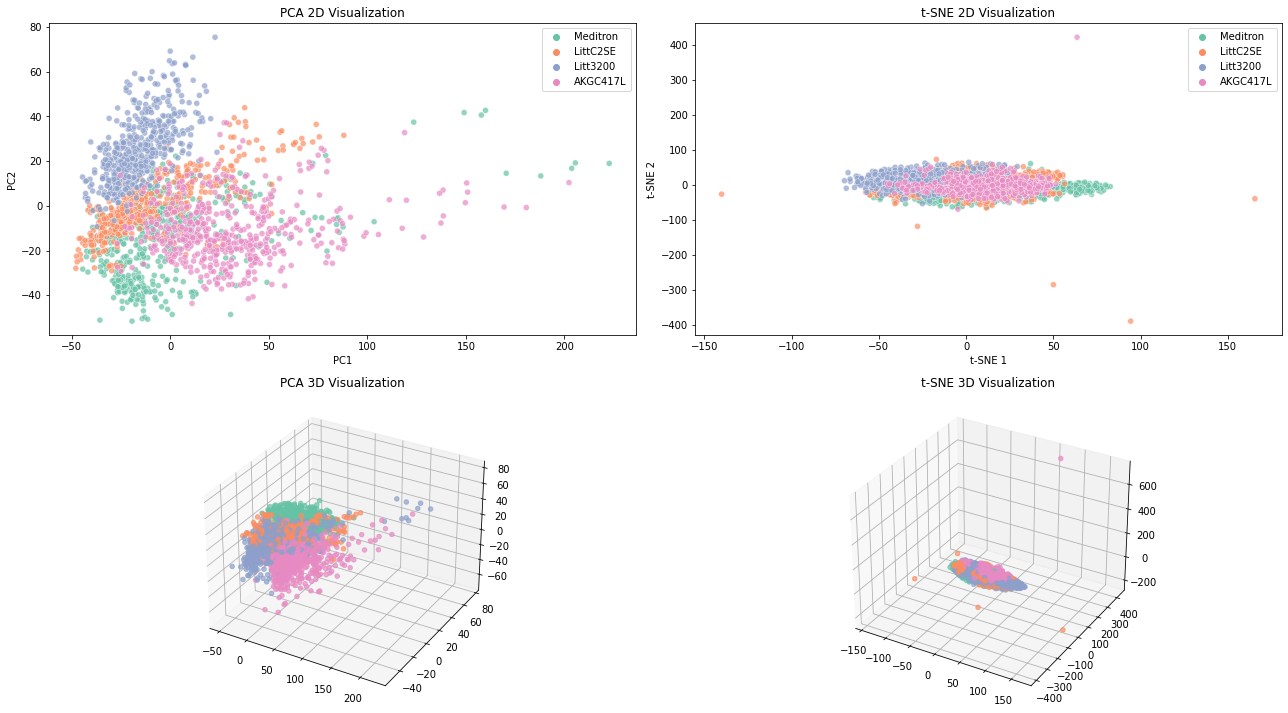

In [ ]:
from utils.visuals_and_statistics_plots import perform_pca_and_tsne

# Count samples per device
device_counts = Counter(device_labels)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by choosing at random
selected_idxs = []

for device in device_counts:
    idxs = np.where(device_labels == device)[0]
    chosen = np.random.choice(idxs, size=min_count, replace=False)
    selected_idxs.extend(chosen)

X_balanced = raw_features[selected_idxs]
y_balanced = device_labels[selected_idxs]

# Run PCA & t-SNE on balanced dataset
perform_pca_and_tsne(
    feature_matrix=X_balanced,
    labels=y_balanced,
    pca_components=0.90,
    tsne_components=3,
    perplexity=30
)

FEATURE DISTRIBUTION

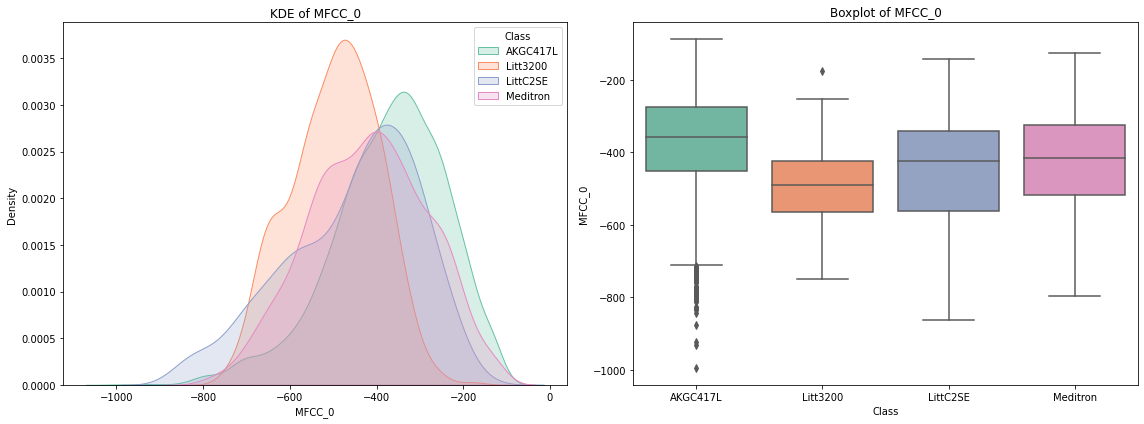

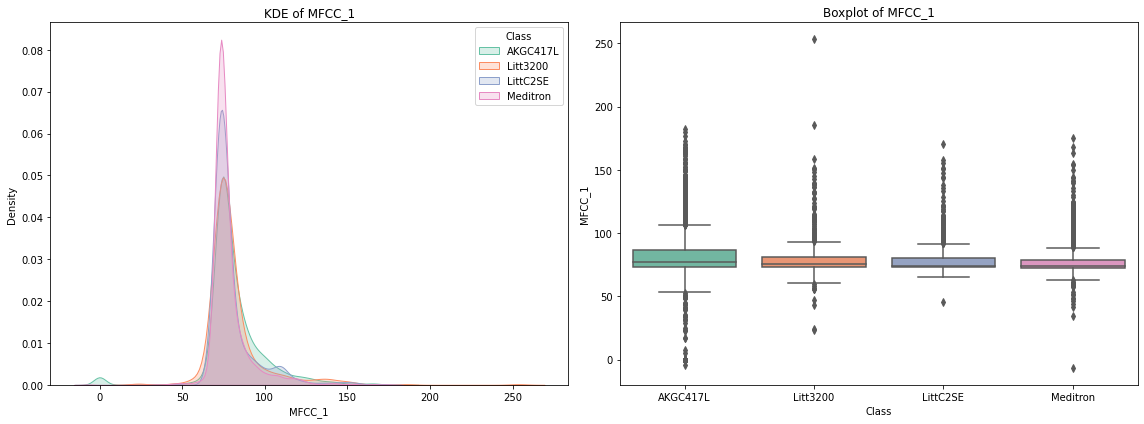

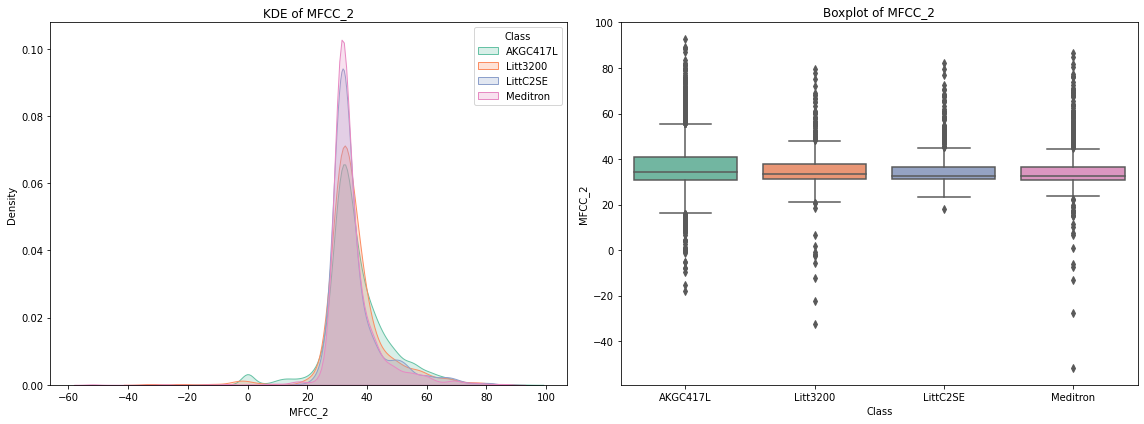

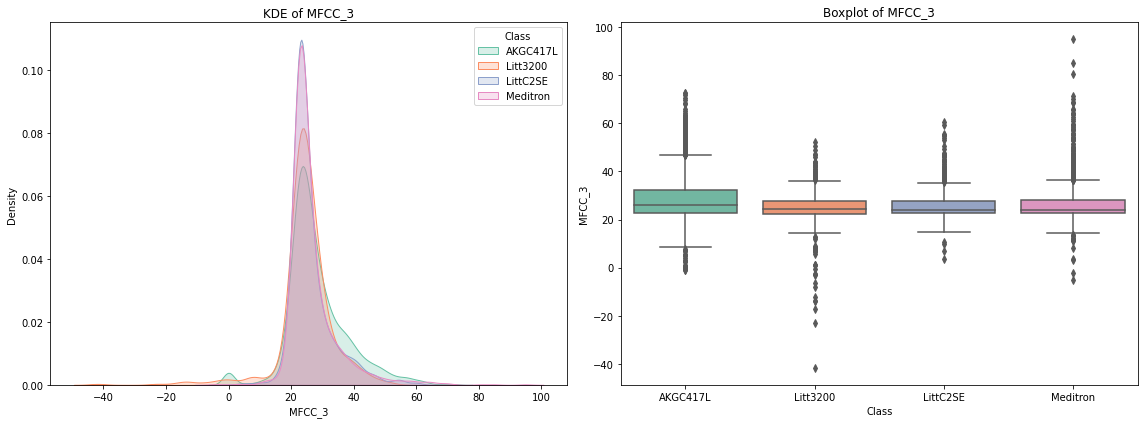

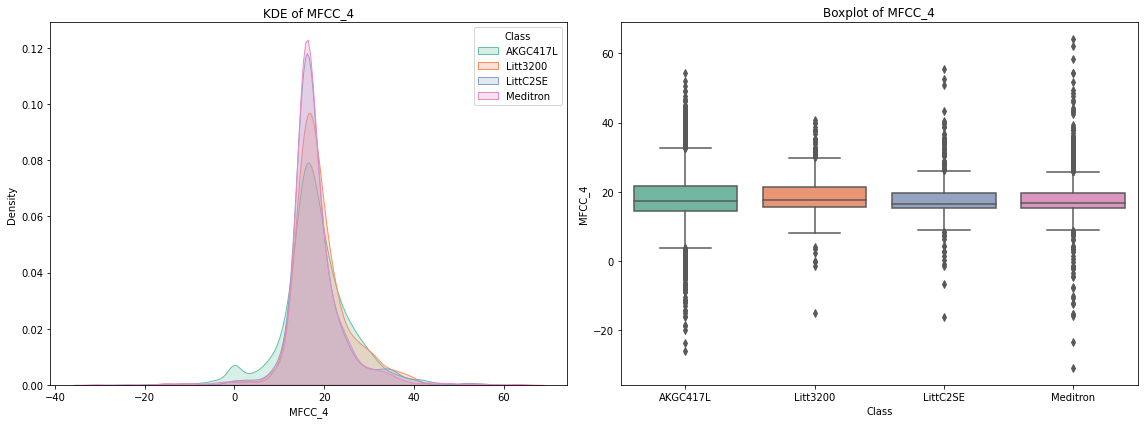

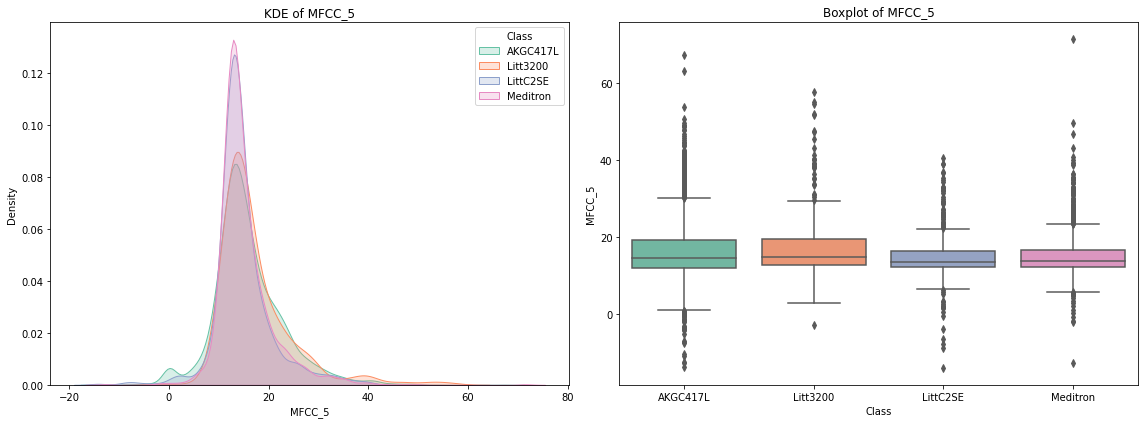

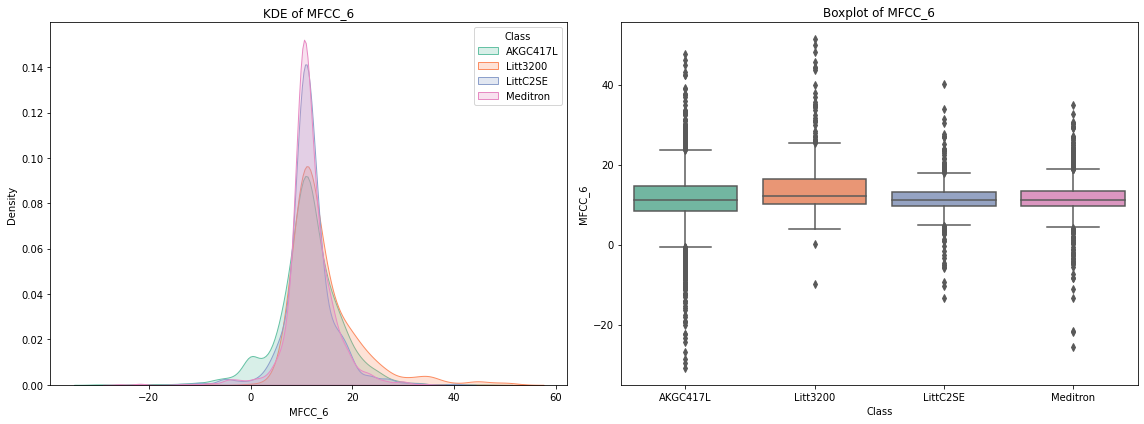

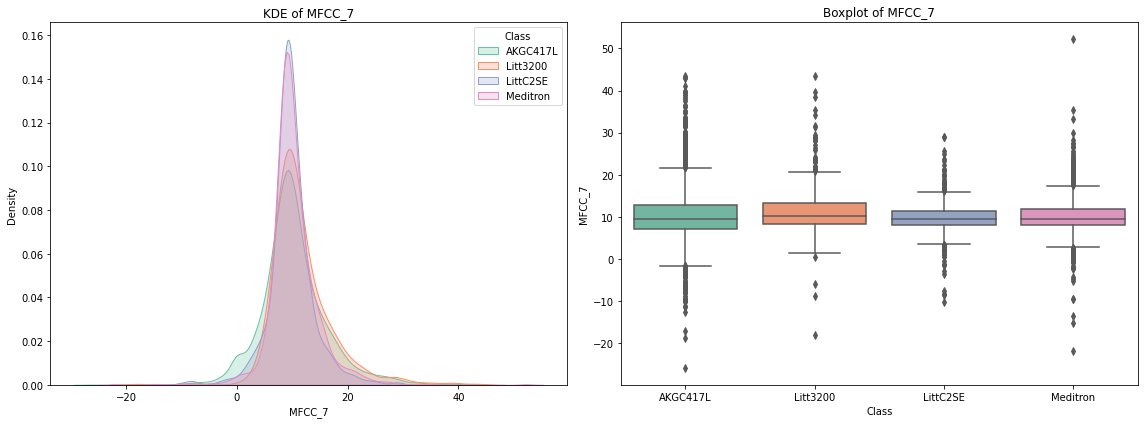

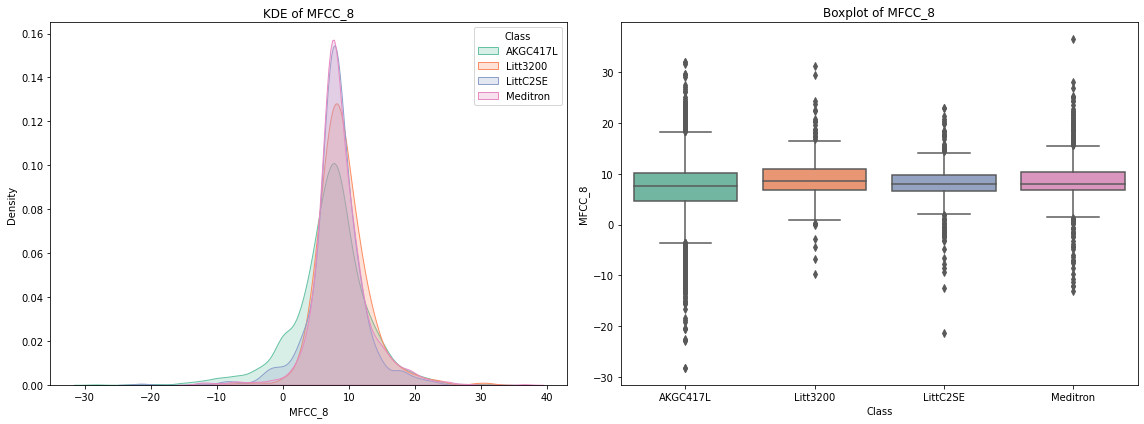

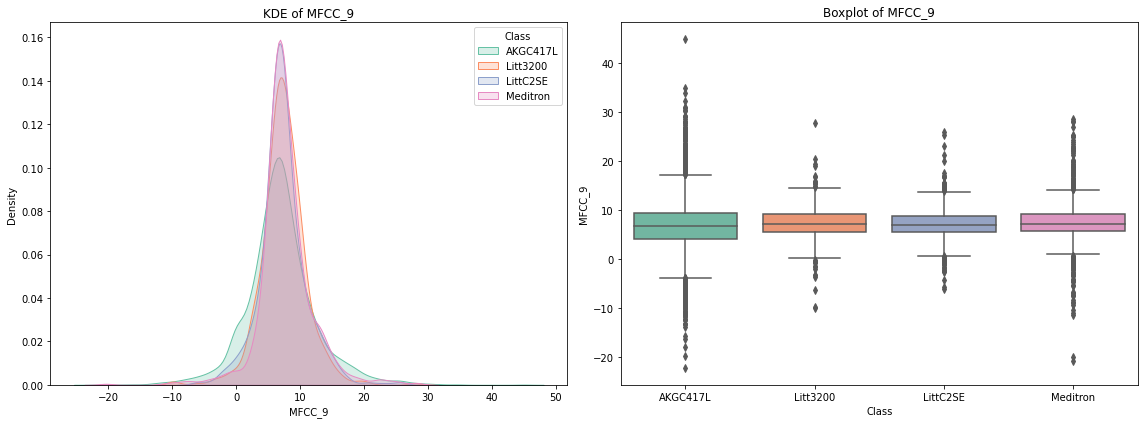

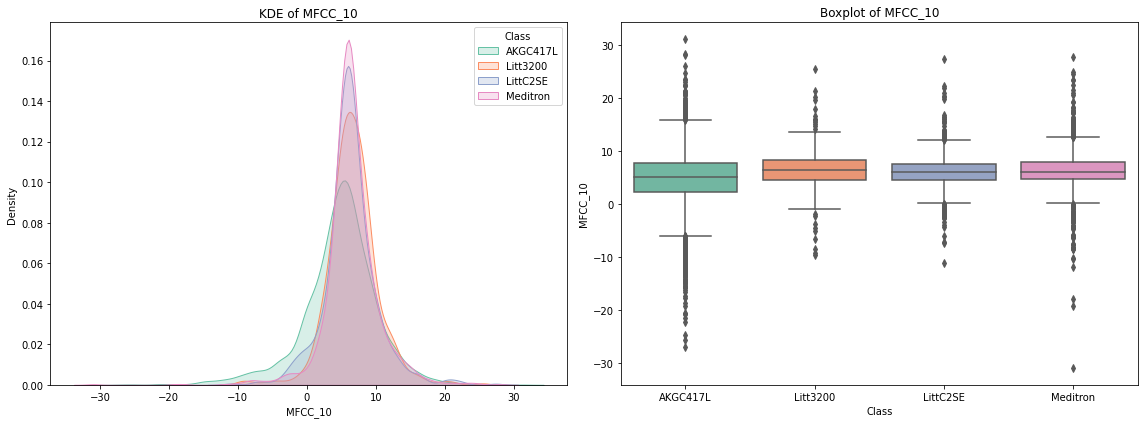

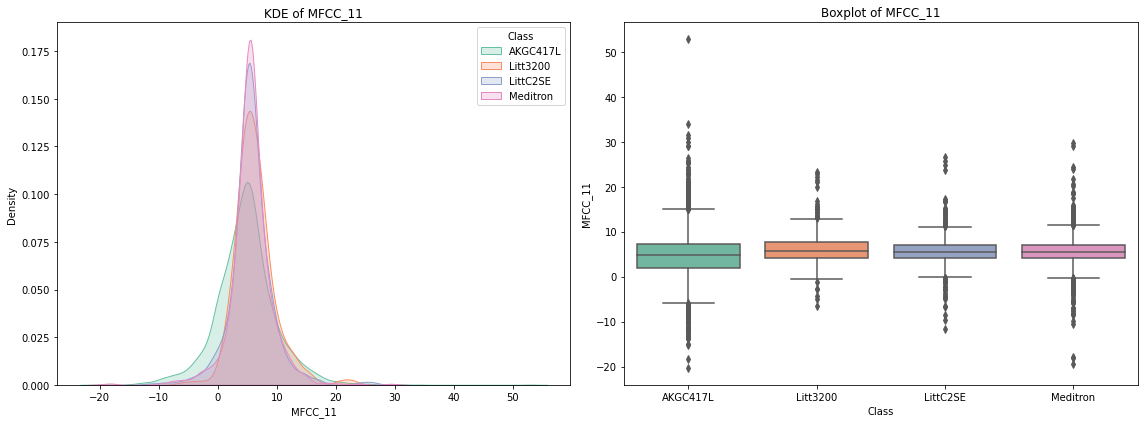

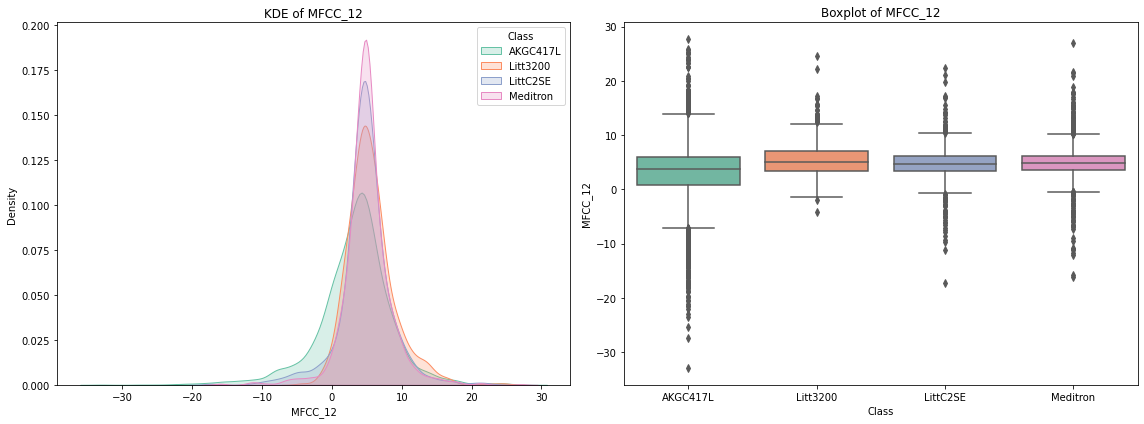

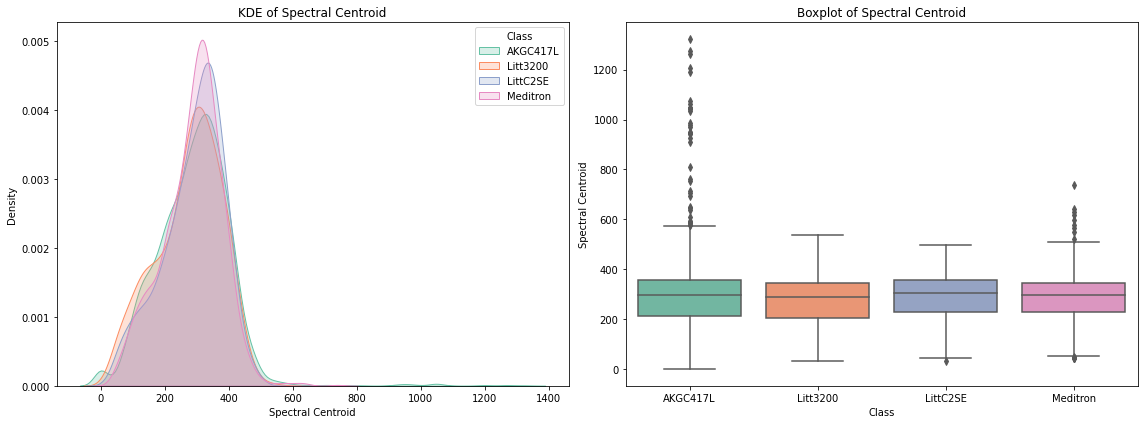

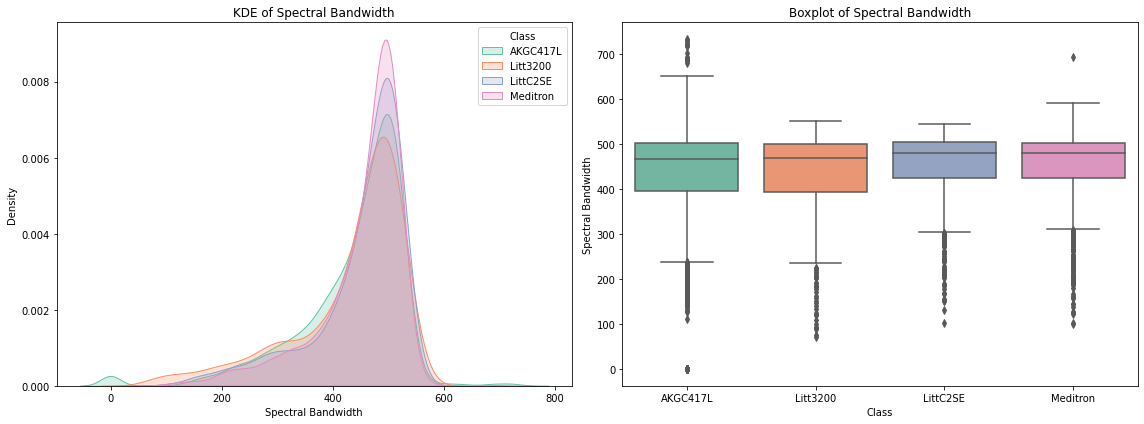

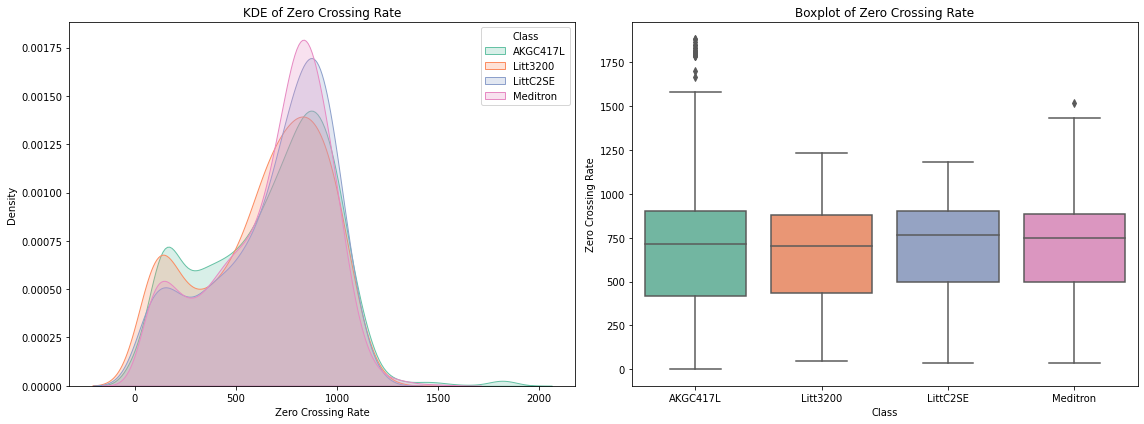

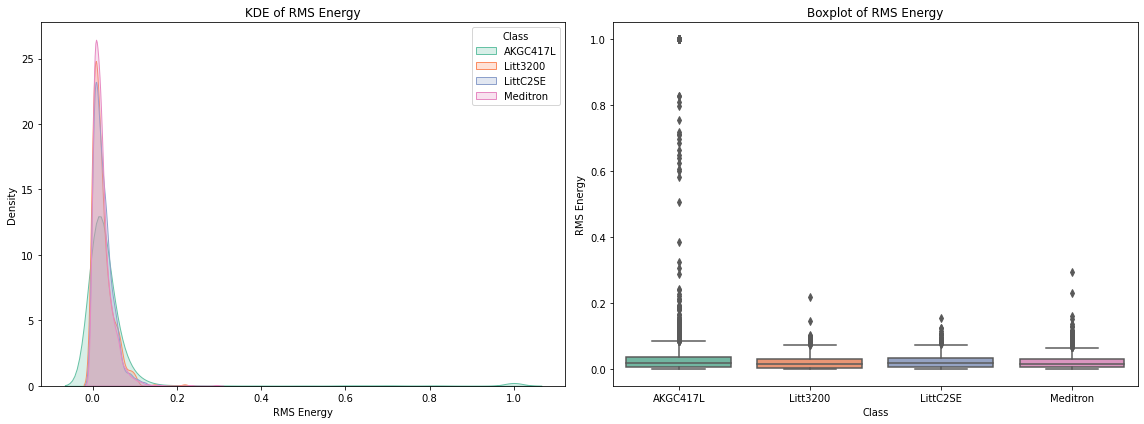

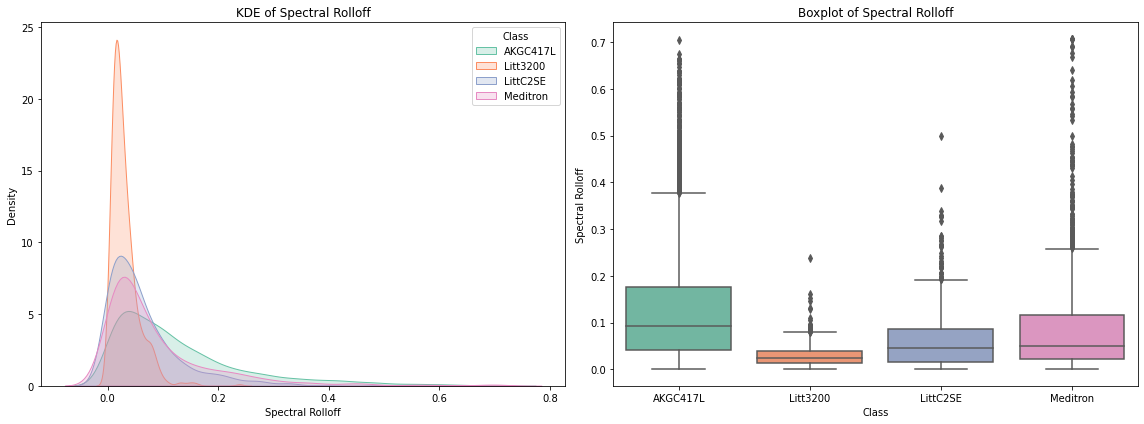

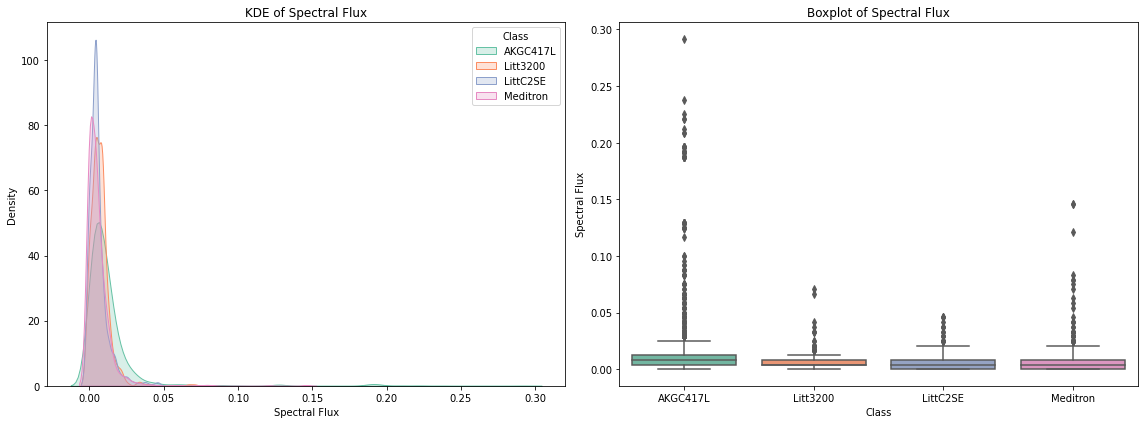

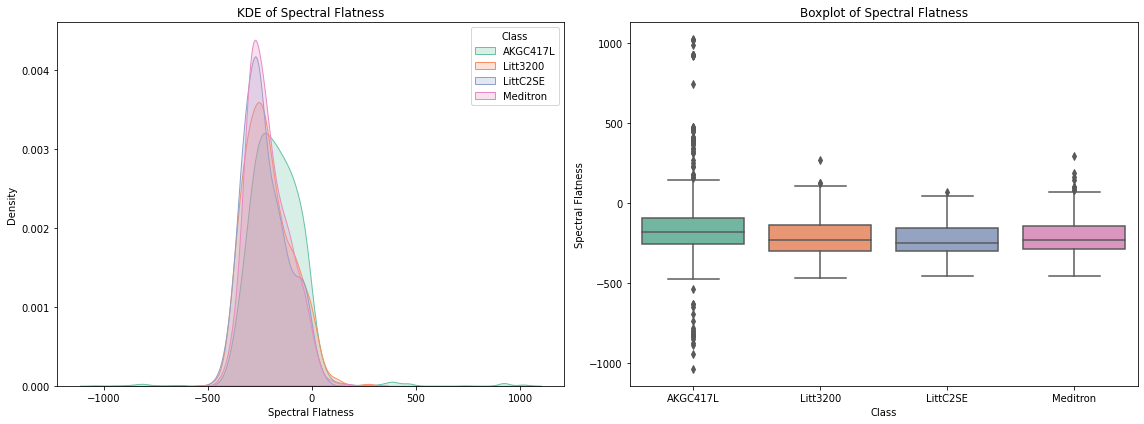

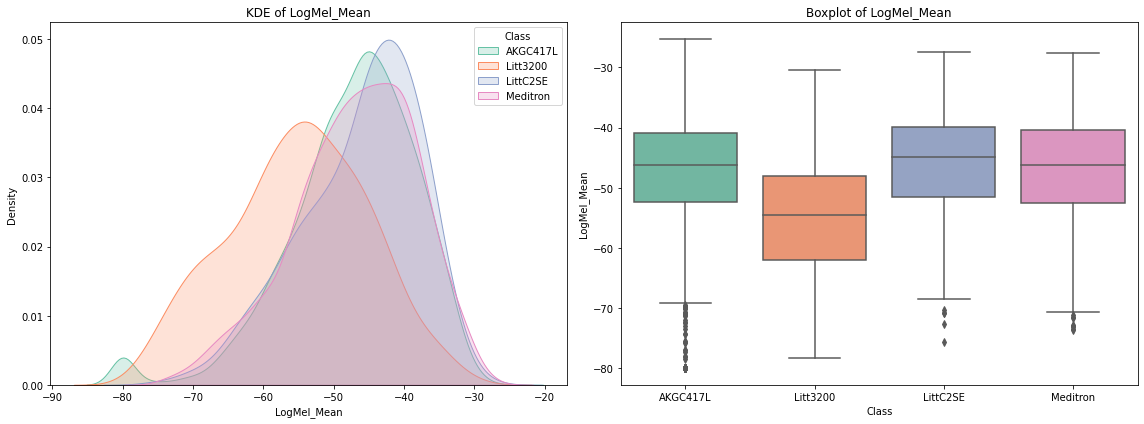

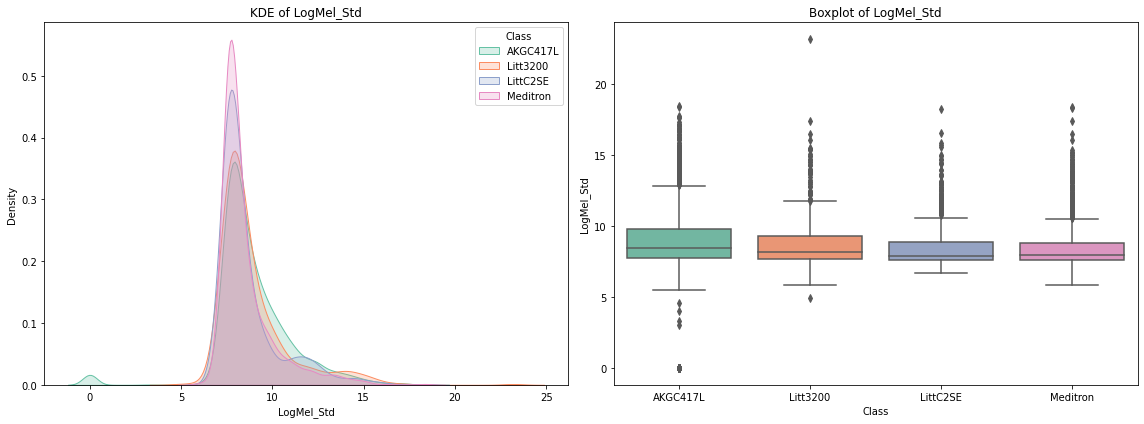

In [ ]:
from utils.visuals_and_statistics_plots import plot_feature_distributions

# Plot
plot_feature_distributions(
    features=raw_features,
    labels=device_labels,
    feature_names=FEATURE_NAMES,
    label_palette="Set2"
)

Calculate Mean Magnitude Response for each device

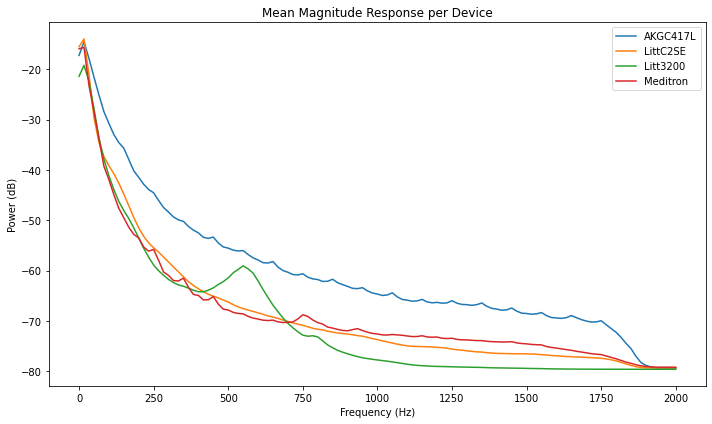

In [49]:
device_signals = {d: [] for d in devices}

for fname in os.listdir(RAW_CYCLE_FOLDER):
    if fname.endswith(".wav"):
        device = next((d for d in devices if d in fname), None)
        if device:
            y, _ = librosa.load(os.path.join(RAW_CYCLE_FOLDER, fname), sr=SAMPLING_RATE)
            device_signals[device].append(y)

# Calculate the mean magnitude response of each device
plt.figure(figsize=(10, 6))

for device in devices:
    signals = device_signals[device]

    all_psd = []
    for y in signals:
        # STFT to Power Spectrogram
        S = np.abs(librosa.stft(y, n_fft=FRAME_SIZE, hop_length=HOP_SIZE))**2
        S_db = librosa.power_to_db(S, ref=np.max)
        mean_spectrum = np.mean(S_db, axis=1)  # Get mean value over time
        all_psd.append(mean_spectrum)

    avg_psd = np.mean(np.stack(all_psd), axis=0)
    freqs = librosa.fft_frequencies(sr=SAMPLING_RATE, n_fft=FRAME_SIZE)
    plt.plot(freqs, avg_psd, label=device)

plt.title("Mean Magnitude Response per Device")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.legend()
plt.tight_layout()
plt.show()

Train a Domain Classifier (RF) to see if the features are domain invariant before applying the correction

In [ ]:
# Load .npy files
merged_features = np.load("raw_features.npy")
device_labels = np.load("device_labels.npy")

# Count samples per device
device_counts = Counter(device_labels)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by choosing at random
selected_idxs = []

for device in device_counts:
    idxs = np.where(device_labels == device)[0]
    chosen = np.random.choice(idxs, size=min_count, replace=False)
    selected_idxs.extend(chosen)

X_balanced = merged_features[selected_idxs]
y_balanced = device_labels[selected_idxs]

le = LabelEncoder()
y = le.fit_transform(y_balanced)
device_names = le.classes_

scaler = StandardScaler()
X = scaler.fit_transform(X_balanced)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation 
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

# Evaluation
print("Accuracy per fold:", np.round(scores, 4))
print("Mean accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))

Accuracy per fold: [0.8706 0.8756 0.8955 0.9002 0.8778]
Mean accuracy: 0.8840 ± 0.0117


Apply Spectrum Correction

We choose 'AKGC417L' as the Reference Device in order to apply Spectrum Correction to make all the recording devices spectra more similar. 'AKGC417L' is the most neutral domain of all since it doesn't form clear cluster and overlaps with many points on the 2D plane. Then we check again the distributions of the features to see if they have aligned more than before. This would mean that some of the domain shift has been removed.

In [14]:
from utils.spectrum_correction import SpectrumCorrection

CORRECTED_FOLDER = "corrected_audio_dcse"
os.makedirs(CORRECTED_FOLDER, exist_ok=True)

# Get device segments
device_segments = {device: [] for device in devices}
device_files = {device: [] for device in devices}

for fname in os.listdir(RAW_CYCLE_FOLDER):
    if fname.endswith(".wav"):
        device = next((d for d in devices if d in fname), None)
        if device:
            path = os.path.join(RAW_CYCLE_FOLDER, fname)
            y, _ = librosa.load(path, sr=4000)
            device_segments[device].append(y)
            device_files[device].append((fname, y))

# Aligned segments 
min_files = min(len(device_segments[d]) for d in devices)
aligned_segments = []
for i in range(min_files):
    aligned_segments.append({device: device_segments[device][i] for device in devices})

# Fit correction 
correction = SpectrumCorrection(num_fft=FRAME_SIZE, hop_length=HOP_SIZE)
correction.fit(aligned_segments, reference=REFERENCE_DEVICE)

# Apply correction
for device in devices:
    if device == REFERENCE_DEVICE:
        continue
    for fname, y in device_files[device]:
        y_corr = correction.transform_wave(y, device)
        sf.write(os.path.join(CORRECTED_FOLDER, fname), y_corr, SAMPLING_RATE)

Extract acoustic features from the corrected .wav files

In [15]:
from utils.audio_preprocessing import extract_acoustic_features

# === Paths ===
CORRECTED_FOLDER = "corrected_audio_dcse"
OUTPUT_FEATURE_FILE = "corrected_features.npy"

feature_list = []

wav_files = [f for f in os.listdir(CORRECTED_FOLDER) if f.endswith(".wav")]

for fname in tqdm(wav_files, desc="Extracting features from corrected files"):
    path = os.path.join(CORRECTED_FOLDER, fname)
    y, sr = librosa.load(path, sr=SAMPLING_RATE)

    feats = extract_acoustic_features(
        y, sr,
        frame_size=FRAME_SIZE,
        hop_size=HOP_SIZE,
        n_mfcc=N_MFCC,
        n_mels=N_MELS
    )

    feats_flattened = feats.flatten()
    feature_list.append(feats_flattened)

# Save as .npy
features_array = np.vstack(feature_list)
np.save(OUTPUT_FEATURE_FILE, features_array)

Extracting features from corrected files: 100%|██████████| 2552/2552 [00:59<00:00, 42.99it/s]


Add the features of the raw AKGC417L cycles

In [16]:
corrected_features = np.load("corrected_features.npy")
raw_features = np.load("raw_features.npy")
raw_filenames = np.load("raw_filenames.npy")

# Choose reference device 
REFERENCE_DEVICE = "AKGC417L"
mask_reference = np.array([REFERENCE_DEVICE in fname for fname in raw_filenames])

reference_features = raw_features[mask_reference]             # raw features for AKGC417L
reference_filenames = raw_filenames[mask_reference]           # corrected features for other devices

corrected_filenames = raw_filenames[~mask_reference]          # filenames for the other devices

# Merge the two arrays
all_features = np.vstack([reference_features, corrected_features])
all_filenames = np.concatenate([reference_filenames, corrected_filenames])

# Save in .npy files
np.save("merged_features.npy", all_features)
np.save("merged_filenames.npy", all_filenames)

New PCA / t-SNE on corrected Dataset

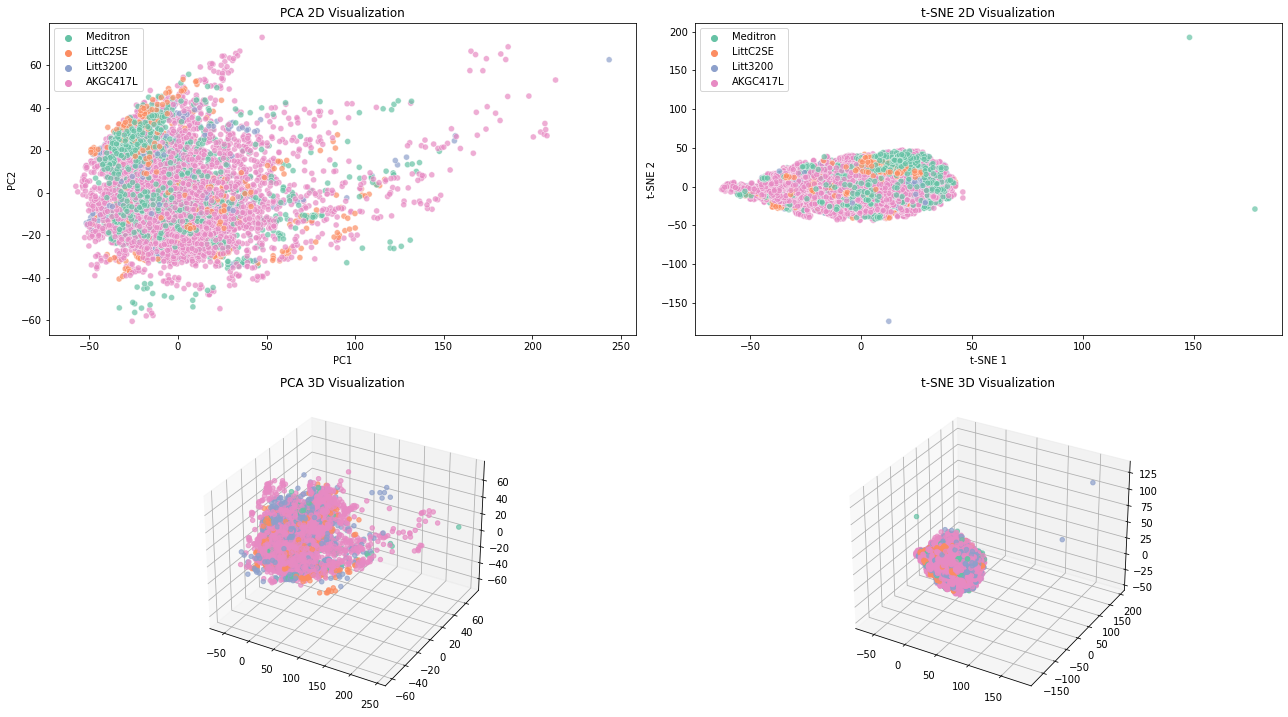

In [17]:
from utils.visuals_and_statistics import perform_pca_and_tsne

# Load the .npy files
merged_features = np.load("merged_features.npy")             
device_labels = np.load("device_labels.npy")   

# Run PCA and t-SNE
perform_pca_and_tsne(
    feature_matrix=merged_features,
    labels=device_labels,
    pca_components=0.90,   # Keep 90% of variance
    tsne_components=3,     # For 3D clustering
    perplexity=30
)

Use a Random Forest Classifier to measure the efficiency of Spectrum Correction. The goal is to achieve accuracy close to 25% (1/4 which is the random baseline), so that the Model cannot discriminate between the 4 devices. For a more fair result we use equal amount of instances for each device.

In [20]:
# Load .npy files
merged_features = np.load("merged_features.npy")
device_labels = np.load("device_labels.npy")

# Count samples per device
device_counts = Counter(device_labels)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by choosing at random
selected_idxs = []

for device in device_counts:
    idxs = np.where(device_labels == device)[0]
    chosen = np.random.choice(idxs, size=min_count, replace=False)
    selected_idxs.extend(chosen)

X_balanced = merged_features[selected_idxs]
y_balanced = device_labels[selected_idxs]

le = LabelEncoder()
y = le.fit_transform(y_balanced)
device_names = le.classes_

scaler = StandardScaler()
X = scaler.fit_transform(X_balanced)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation 
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

# Evaluation
print("Accuracy per fold:", np.round(scores, 4))
print("Mean accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))

Accuracy per fold: [0.4453 0.5    0.4627 0.4663 0.4888]
Mean accuracy: 0.4726 ± 0.0195
